In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import seaborn as sns
from scipy.stats import sem
from scipy.stats import binom_test
from scipy.stats import wilcoxon

from src import encodeMeta
from src import utils
from src import mobi

### Get Cell Line Specific TFs and TF_common TFs

In [2]:
metadata = encodeMeta.unique_TF_parser("/home/jg2447/slayman/motif_inference/result/metadata/human-GM12878.txt")
u_TF_files, u_TF_names, u_TF_files_w_motif, u_TF_names_w_motif, u_motif_files = metadata[5:]
TF_GM12878 = u_TF_names_w_motif

metadata = encodeMeta.unique_TF_parser("/home/jg2447/slayman/motif_inference/result/metadata/human-K562.txt")
u_TF_files, u_TF_names, u_TF_files_w_motif, u_TF_names_w_motif, u_motif_files = metadata[5:]
TF_K562 = u_TF_names_w_motif

TF_common = set.intersection(set(TF_GM12878), set(TF_K562))
TF_common = np.array(list(TF_common))
TF_common.sort()

### compare gene expression

In [3]:
def tpm_input(f, factor=100000):
    df = pd.read_csv(f, sep="\t")
    df = df.sort_values("TPM", ascending=False)
    coef = df.iloc[:5,:]['TPM'].mean() / factor
    df["TPM_new"] = df["TPM"] / coef
    return(df)

In [4]:
tf_name2id = pd.read_csv("/home/jg2447/slayman/data/ensembl_biomart/ensembl_hg19_geneID_geneIDver_geneName_chr.txt", sep="\t", header=None)
tf_name2tid = pd.read_csv("/home/jg2447/slayman/data/ensembl_biomart/ensembl_hg19_transcriptID_transcriptIDver_geneName_chr.txt", sep="\t", header=None)
tf_name2id_common = tf_name2id[tf_name2id[2].isin(TF_common)]

In [5]:
K562 = tpm_input("/home/jg2447/slayman/data/ENCODE_total_RNA_seq_tsv/K562_RNA-seq_gene_rep1_ENCFF139IXQ.tsv")
K562 = pd.merge(K562, tf_name2id, left_on="gene_id", right_on=1)

GM12878 = tpm_input("/home/jg2447/slayman/data/ENCODE_total_RNA_seq_tsv/GM12878_RNA-seq_gene_rep1_ENCFF009ZXH.tsv")
GM12878 = pd.merge(GM12878, tf_name2id, left_on="gene_id", right_on=1)

In [6]:
TPM_GM12878 = GM12878[GM12878['gene_id'].isin(tf_name2id_common[1])].sort_values(2)["TPM"].values
TPM_K562 = K562[K562['gene_id'].isin(tf_name2id_common[1])].sort_values(2)["TPM"].values

TPM_new_GM12878 = GM12878[GM12878['gene_id'].isin(tf_name2id_common[1])].sort_values(2)["TPM_new"].values
TPM_new_K562 = K562[K562['gene_id'].isin(tf_name2id_common[1])].sort_values(2)["TPM_new"].values

### compare motif enrichment

In [7]:
data_type = "humanGM12878"
humanGM12878_df1 = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankSPP_100.txt" % data_type, sep="\t").sort_values("0")
humanGM12878_df2 = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankColdness_100.txt" % data_type, sep="\t").sort_values("0")
data_type = "humanK562"
humanK562_df1 = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankSPP_100.txt" % data_type, sep="\t").sort_values("0")
humanK562_df2 = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankColdness_100.txt" % data_type, sep="\t").sort_values("0")

In [8]:
me_spp_GM12878 = humanGM12878_df1[humanGM12878_df1['0'].isin(TF_common)]["250"].values
me_cold_GM12878 = humanGM12878_df2[humanGM12878_df2['0'].isin(TF_common)]["250"].values

me_spp_K562 = humanK562_df1[humanK562_df1['0'].isin(TF_common)]["250"].values
me_cold_K562 = humanK562_df2[humanK562_df2['0'].isin(TF_common)]["250"].values

### compare motif inference

In [9]:
data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/tomtom_summary/DREME_RankSPP_100_count_top5.txt",
    sep="\t", header=None)
GM12878_spp = data[data[0].isin(TF_common)].sort_values(0)[1].values
data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/tomtom_summary/DREME_RankLinear_1.0_100_count_top5.txt",
    sep="\t", header=None)
GM12878_cold = data[data[0].isin(TF_common)].sort_values(0)[1].values

data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/tomtom_summary/DREME_RankSPP_100_known_hit_top5.txt",
    sep="\t", header=None)
GM12878_spp_known_hit = data[data[0].isin(TF_common)].sort_values(0)[1].values
data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanGM12878/tomtom_summary/DREME_RankLinear_1.0_100_known_hit_top5.txt",
    sep="\t", header=None)
GM12878_cold_known_hit = data[data[0].isin(TF_common)].sort_values(0)[1].values


data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/tomtom_summary/DREME_RankSPP_100_count_top5.txt",
    sep="\t", header=None)
K562_spp = data[data[0].isin(TF_common)].sort_values(0)[1].values
data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/tomtom_summary/DREME_RankLinear_1.0_100_count_top5.txt",
    sep="\t", header=None)
K562_cold = data[data[0].isin(TF_common)].sort_values(0)[1].values

data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/tomtom_summary/DREME_RankSPP_100_known_hit_top5.txt",
    sep="\t", header=None)
K562_spp_known_hit = data[data[0].isin(TF_common)].sort_values(0)[1].values
data = pd.read_csv(
    "/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/humanK562/tomtom_summary/DREME_RankLinear_1.0_100_known_hit_top5.txt",
    sep="\t", header=None)
K562_cold_known_hit = data[data[0].isin(TF_common)].sort_values(0)[1].values

### combined result

In [10]:
result = pd.DataFrame([TF_common, TPM_GM12878, TPM_K562, me_spp_GM12878, me_spp_K562, GM12878_spp, K562_spp]).transpose()
result.columns = ["TF", "exp1", "exp2", "me1", "me2", "mi1", "mi2"]

In [11]:
[result.query("me1 < me2 and mi1 < mi2").shape[0],
result.query("me1 < me2 and mi1 >= mi2").shape[0],
result.query("me1 >= me2 and mi1 < mi2").shape[0],
result.query("me1 >= me2 and mi1 >= mi2").shape[0]]

[14, 11, 5, 14]

In [12]:
from scipy.stats import fisher_exact
fisher_exact(np.array([[14, 11],[5, 14]]), alternative="greater")

(3.5636363636363635, 0.0473259324510196)

In [13]:
wilcoxon(result["me2"], result["me1"], )

WilcoxonResult(statistic=346.0, pvalue=0.12512739580386578)

In [14]:
wilcoxon(result["mi2"], result["mi1"], )

WilcoxonResult(statistic=116.5, pvalue=0.07047748968233411)

In [15]:
result["ratio"] = result["exp2"]/result["exp1"].fillna(0)
result = result.sort_values("ratio", ascending=False)
highK = result.iloc[:result.shape[0]//2,]
lowK = result.iloc[result.shape[0]//2:,]

### plot

In [16]:
def plt_ax_trim(ax_i):
    """
    From sns.utils -> despine function -> trim parameter
    See https://github.com/mwaskom/seaborn/blob/master/seaborn/utils.py
    """
    xticks = ax_i.get_xticks()
    if xticks.size:
        firsttick = np.compress(xticks >= min(ax_i.get_xlim()),
                                xticks)[0]
        lasttick = np.compress(xticks <= max(ax_i.get_xlim()),
                               xticks)[-1]
        ax_i.spines['bottom'].set_bounds(firsttick, lasttick)
        ax_i.spines['top'].set_bounds(firsttick, lasttick)
        newticks = xticks.compress(xticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_xticks(newticks)

    yticks = ax_i.get_yticks()
    if yticks.size:
        firsttick = np.compress(yticks >= min(ax_i.get_ylim()),
                                yticks)[0]
        lasttick = np.compress(yticks <= max(ax_i.get_ylim()),
                               yticks)[-1]
        ax_i.spines['left'].set_bounds(firsttick, lasttick)
        ax_i.spines['right'].set_bounds(firsttick, lasttick)
        newticks = yticks.compress(yticks <= lasttick)
        newticks = newticks.compress(newticks >= firsttick)
        ax_i.set_yticks(newticks)

In [17]:
# def plt_box(ax, data1, data2):
#     bp = ax.boxplot([data1, data2], 
#                        positions=[1,1.25],
#                        widths=0.15,
#                        flierprops=dict(marker=".", markerfacecolor='black', markersize=0.8, linestyle='none'),
#                        medianprops = dict(linestyle='-', linewidth=0.5, color='black'),
#                        boxprops=dict(linewidth=0.5),
#                        capprops=dict(linewidth=0.5),
#                        whiskerprops=dict(linewidth=0.5))
#     ax.set_xlim([0.8, 1.6])
    
#     plt_ax_trim(ax)
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)

#     ax.set_xticklabels(labels=["GM12878", "K562"], rotation=90, fontsize=5)
#     ax.xaxis.set_tick_params(size=0, pad=-1, labelsize=5)
#     ax.yaxis.set_tick_params(size=2.5, pad=1, labelsize=5)

#     for i in range(2):
#         box = bp['boxes'][i]
#         boxX = []
#         boxY = []
#         for j in range(5):
#             boxX.append(box.get_xdata()[j])
#             boxY.append(box.get_ydata()[j])
#         box_coords = np.column_stack([boxX, boxY])
#         ax.add_patch(Polygon(box_coords, facecolor=colors[i % 2]))

# #     med = bp['medians'][0]
# #     medianX = []
# #     medianY = []

# #     medianX.append(med.get_xdata()[0])
# #     medianY.append(med.get_ydata()[0])
# #     ax.plot(medianX, medianY, 'k')
# #     medians[i] = medianY[0]

In [18]:
# def plt_pie(ax, data1, data2, data3, data4):

#     diff = data2 - data1
#     increase = np.sum(diff>0)
#     nochange = np.sum(diff==0)
#     decrease = np.sum(diff<0)

#     pie_colors = ["#70db89", "#00aca9", "#fff852"]
#     pie_colors = ["#5975a4", "#b55d60", "#5f9e6e"]
#     ax.pie(
#         [increase,nochange,decrease], 
#         labels=None,
#         colors=[pie_colors[0], pie_colors[1], pie_colors[2]],
#         textprops={'fontsize': 14},
#         radius=1.25,
#         counterclock=False,
#         wedgeprops=dict(width=0.3125, edgecolor='k', lw=0.25),
#         startangle=90)
    
#     diff = data4 - data3
#     increase = np.sum(diff>0)
#     nochange = np.sum(diff==0)
#     decrease = np.sum(diff<0)

#     ax.pie(
#         [increase,nochange,decrease], 
#         labels=None,
#         colors=[pie_colors[0], pie_colors[1], pie_colors[2]],
#         textprops={'fontsize': 14},
#         radius=0.9375,
#         counterclock=False,
#         wedgeprops=dict(width=0.3125, edgecolor='k', lw=0.25),
#         startangle=90)
    
#     ax.annotate("High expr", xy=(1.25,0.05), ha='left', va='center', rotation=-90, fontsize=4)
#     ax.annotate("Low expr", xy=(0.2,0.05), ha='left', va='center', rotation=-90, fontsize=4)

In [19]:
figsize = (3.2, 2.8)
panel_number_fs = 8
x_tick_label_fs = 5
y_tick_label_fs = 5
x_label_fs = 6
y_label_fs = 6
title_fs = 5
legend_fs = 5

colors = ["#5975a4", "#5f9e6e"]

In [20]:
def plt_bar(ax, data, data2):
    ##
    ax.bar(
        [0,0.45],
        data, 
        width=0.4,
        color=colors, linewidth=0.3, edgecolor="black")

    _, caps, sticks = ax.errorbar(
        x=[0,0.45],
        y=data,
        yerr=data2,
        fmt=".", lw=1, capsize=1, markersize=0, elinewidth=0.5, ecolor=(0.1, 0.1, 0.1, 0.75))
    for cap in caps:
         cap.set_markeredgewidth(0.5)

    ax.set_xlim([-0.45, 0.9])
    ax.get_xaxis().set_ticks([])
    ax.get_xaxis().set_ticklabels([])
    ax.get_xaxis().set_tick_params(size=0, pad=2, labelsize=x_tick_label_fs)

    # ax.get_yaxis().set_ticks([0,0.5,1,1.5,2])
    ax.get_yaxis().set_tick_params(size=2.5, width=0.5, pad=1, labelsize=y_tick_label_fs)

    #ax.legend([ax.patches[0], ax.patches[1]], ["GM12878", "K562"], fontsize=legend_fs, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.4, 1.15))

    plt_ax_trim(ax)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)


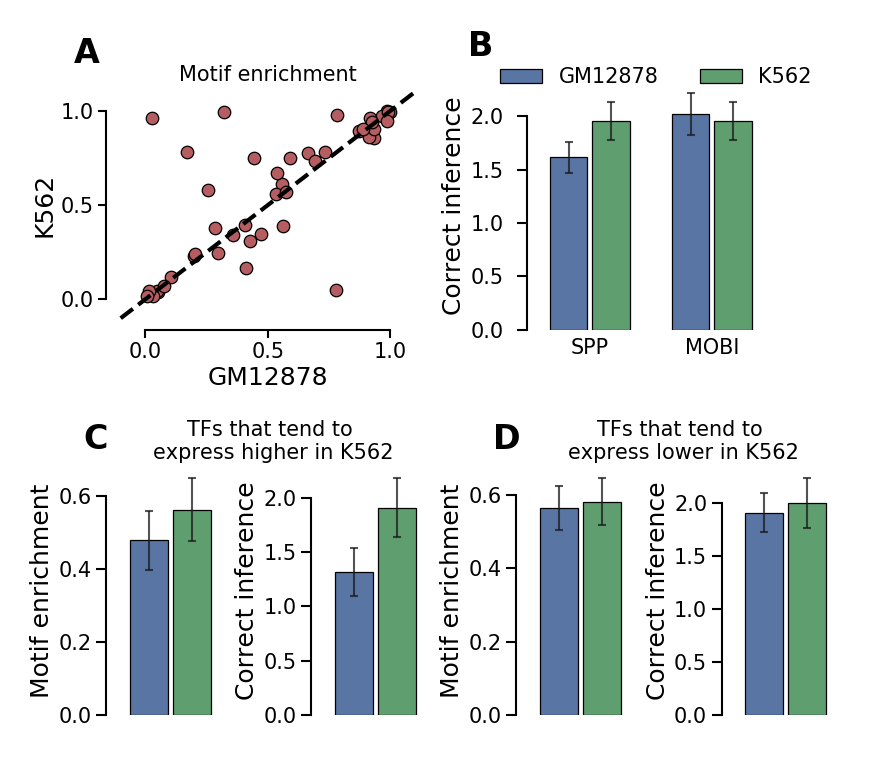

In [21]:
sns.set_context("paper")

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    gridspec_kw={'hspace': 0.55},
    figsize=figsize, dpi=300)

axs[0].axis('off')
axs[1].axis('off')

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=axs[0], wspace=0.3)

##
ax = plt.subplot(gs[0,0])
ax.plot(result["me1"],result["me2"], "o", ms=3, markeredgewidth=0.3, markeredgecolor='k', color="#b55d60")
ax.plot([-0.1,1.1], [-0.1,1.1], "k--", lw=1)
ax.set_xticks([0,0.5,1])
ax.set_yticks([0,0.5,1])
ax.set_xlabel("GM12878", size=x_label_fs, labelpad=1)
ax.set_ylabel("K562", size=y_label_fs, labelpad=1)
ax.get_xaxis().set_tick_params(size=2, width=0.5, labelsize=x_tick_label_fs, pad=1)
ax.get_yaxis().set_tick_params(size=2, width=0.5, labelsize=y_tick_label_fs, pad=1)
ax.set_title("Motif enrichment", size=title_fs, pad=0)
plt_ax_trim(ax)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.text(-0.10, 1.07, "A", transform=ax.transAxes, size=panel_number_fs, weight='bold')

##
ax = plt.subplot(gs[0,1])
ax.bar(
    [0,0.45,1.3,1.75],
    [GM12878_spp.mean(),K562_spp.mean(),GM12878_cold.mean(),K562_cold.mean()],
    width=0.4,
    color=[colors[0], colors[1], colors[0], colors[1]], linewidth=0.3, edgecolor="black")

_, caps, sticks = ax.errorbar(
    x=[0,0.45,1.3,1.75],
    y=[GM12878_spp.mean(),K562_spp.mean(),GM12878_cold.mean(),K562_cold.mean()],
    yerr=[sem(GM12878_spp),sem(K562_spp),sem(GM12878_cold),sem(K562_cold)],
    fmt=".", lw=1, capsize=1, markersize=0, elinewidth=0.5, ecolor=(0.1, 0.1, 0.1, 0.75))
for cap in caps:
     cap.set_markeredgewidth(0.5)

ax.set_xlim([-0.45, 3])
ax.get_xaxis().set_ticks([0.225, 1.525])
ax.get_xaxis().set_ticklabels(["SPP", "MOBI"])
ax.get_xaxis().set_tick_params(size=0, pad=2, labelsize=x_tick_label_fs)

ax.get_yaxis().set_ticks([0,0.5,1,1.5,2])
ax.get_yaxis().set_tick_params(size=2.5, width=0.5, pad=3, labelsize=y_tick_label_fs)
ax.set_ylabel("Correct inference", fontsize=y_label_fs, labelpad=1)

ax.legend([ax.patches[0], ax.patches[1]], ["GM12878", "K562"], fontsize=legend_fs, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.4, 1.13))

plt_ax_trim(ax)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines["left"].set_linewidth(0.5)

ax.text(-0.18, 1.1, "B", transform=ax.transAxes, size=panel_number_fs, weight='bold')

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=axs[1], wspace=0.6)

ax = plt.subplot(gs[0,0])
plt_bar(ax, [highK['me1'].mean(), highK['me2'].mean()], [highK['me1'].sem(), highK['me2'].sem()])
ax.set_ylabel("Motif enrichment", fontsize=y_label_fs, labelpad=1)
ax.text(-0.18, 1.07, "C", transform=ax.transAxes, size=panel_number_fs, weight='bold')

ax = plt.subplot(gs[0,1])
plt_bar(ax, [highK['mi1'].mean(), highK['mi2'].mean()], [highK['mi1'].sem(), highK['mi2'].sem()])
ax.set_ylabel("Correct inference", fontsize=y_label_fs, labelpad=1)
ax.set_title("TFs that tend to \nexpress higher in K562", fontsize=title_fs, x=-0.3, y=0.93)

ax = plt.subplot(gs[0,2])
plt_bar(ax, [lowK['me1'].mean(), lowK['me2'].mean()], [lowK['me1'].sem(), lowK['me2'].sem()])
ax.set_ylabel("Motif enrichment", fontsize=y_label_fs, labelpad=1)
ax.text(-0.18, 1.07, "D", transform=ax.transAxes, size=panel_number_fs, weight='bold')

ax = plt.subplot(gs[0,3])
plt_bar(ax, [lowK['mi1'].mean(), lowK['mi2'].mean()], [lowK['mi1'].sem(), lowK['mi2'].sem()])
ax.set_ylabel("Correct inference", fontsize=y_label_fs, labelpad=1)
ax.set_title("TFs that tend to \nexpress lower in K562", fontsize=title_fs, x=-0.3, y=0.93)

# plt.show()
plt.savefig("./fig5.pdf", dpi="figure", bbox_inches="tight")